# Tutorial: Save Wave Data (Single File Strategy)

This notebook demonstrates how to consolidate wave data with orbital parameters (L, MLT, MLAT) into a single file following **Single File Strategy**. It also includes examples for calculating Electron gyrofrequency (`fce`) and Equatorial gyrofrequency (`fce_eq`)

> **Note**: This tutorial assumes data has been downloaded using Tutorial 6.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timezone
from pathlib import Path
from astropy import units as u

import el_paso as ep
from el_paso.variable import Variable

# Time range (full day)
start_time = datetime(2018, 4, 12, 0, 0, 0, tzinfo=timezone.utc)
end_time = datetime(2018, 4, 12, 23, 59, 59, tzinfo=timezone.utc)

# File name stems
FILE_STEMS = {
    "wfr": "rbsp-a_wfr-spectral-matrix-diagonal_emfisis-l2_YYYYMMDD_.{6}.cdf",
    "density": "rbsp-a_density_emfisis-l4_YYYYMMDD_.{7}.cdf",
    "mag": "rbsp-a_magnetometer_4sec-sm_emfisis-l3_YYYYMMDD_.{6}.cdf",
    "wave_properties": "rbsp-a_wna-survey-sheath-corrected-e_emfisis-l4_YYYYMMDD_.{6}.cdf"
}

# Paths
DATA_PATH = Path("./wave_data/rbspa/")
SAVE_PATH = Path("./wave_data/processed/")
SAVE_PATH.mkdir(parents=True, exist_ok=True)


## Loading and Processing Density Data

In [2]:
# Extract density data only
density_extraction = [
    ep.ExtractionInfo(
        result_key="Epoch",
        name_or_column="Epoch", 
        unit=ep.units.tt2000,
    ),
    ep.ExtractionInfo(
        result_key="Density",
        name_or_column="density",
        unit=u.cm**(-3),
    ),
]

# Load density data for time range
density_vars = ep.extract_variables_from_files(
    start_time=start_time,
    end_time=end_time,
    file_cadence="daily",
    data_path=DATA_PATH,
    file_name_stem=FILE_STEMS["density"],
    extraction_infos=density_extraction
)


In [3]:
# Convert Epoch to POSIX time and Python datetimes
density_vars["Epoch"].convert_to_unit(ep.units.posixtime)
epoch_data = density_vars["Epoch"].get_data()

# Vectorized conversion (faster than list comprehension)
times = np.array([datetime.fromtimestamp(ts, timezone.utc) for ts in epoch_data])


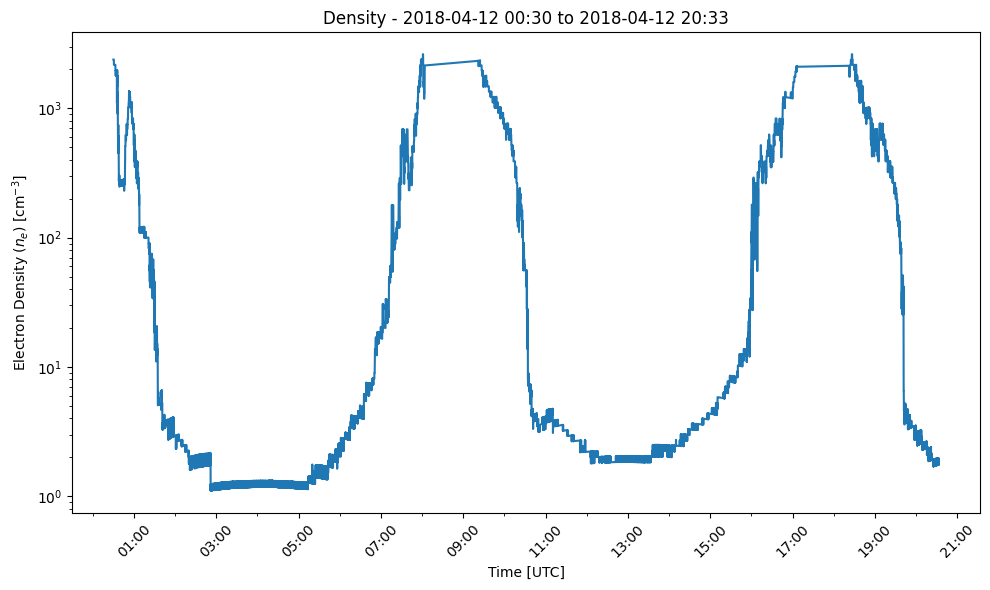

In [4]:
# Plot density time series
fig, ax = plt.subplots(figsize=(10, 6))

density_data = density_vars["Density"].get_data()
ax.plot(times, density_data)

# Formatting
ax.set_ylabel(r'Electron Density ($n_e$) [cm$^{-3}$]')
ax.set_yscale('log')
ax.set_xlabel('Time [UTC]')

# Dynamic title with actual time range
ax.set_title(
    f'Density - {times[0].strftime("%Y-%m-%d %H:%M")} to '
    f'{times[-1].strftime("%Y-%m-%d %H:%M")}', 
    fontsize=12
)

# Time axis formatting
ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))
ax.xaxis.set_minor_locator(mdates.HourLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.show()


In [5]:
# Save density data to single pickle file (DataOrg standard)
output_file = SAVE_PATH / f"rbspa_density_{start_time.strftime('%Y%m%d')}_to_{end_time.strftime('%Y%m%d')}.pickle"

saving_strategy = ep.saving_strategies.SingleFileStrategy(output_file)

ep.save(
    variables_dict=density_vars,
    saving_strategy=saving_strategy,
    start_time=start_time,
    end_time=end_time,
    time_var=density_vars["Epoch"]
)


## Magnetometer Data Processing

Magnetometer data requires cleaning due to spacecraft interference and noise.

The cleaned magnetic field data (Bt) is used to calculate derived parameters:
- L-shell parameter
- Magnetic Local Time (MLT) 
- Magnetic Latitude (MLAT)
- Electron gyrofrequency (fce)
- Equatorial gyrofrequency (fce_eq)


In [6]:
# Extract magnetometer data (CORRECTED)
mag_extraction = [
    ep.ExtractionInfo(result_key="Epoch", name_or_column="Epoch", unit=ep.units.tt2000),
    ep.ExtractionInfo(result_key="Bt", name_or_column="Magnitude", unit=u.nT),  # nanoTesla
    ep.ExtractionInfo(result_key="Coordinates", name_or_column="coordinates", unit=u.km), ]

# Load magnetometer data
mag_vars = ep.extract_variables_from_files(
    start_time=start_time,
    end_time=end_time,
    file_cadence="daily",
    data_path=DATA_PATH,
    file_name_stem=FILE_STEMS["mag"],
    extraction_infos=mag_extraction
)


### Cleaning Magnetometer Data

Apply spike removal and quality filtering to magnetometer data using the custom cleaning function.

Removes:
- Negative or zero Bt values (unphysical)
- Spikes where |ΔBt| ≥ 500 nT between samples


In [7]:
# Clean magnetometer data (removes Bt ≤ 0, |ΔBt| ≥ 500 nT spikes)
mag_vars = ep.processing.clean_magnetometer_variables(mag_vars)

# Add derived parameters (L, MLT, MLAT, fce, fce_eq) 
mag_vars = ep.processing.add_derived_params(mag_vars)


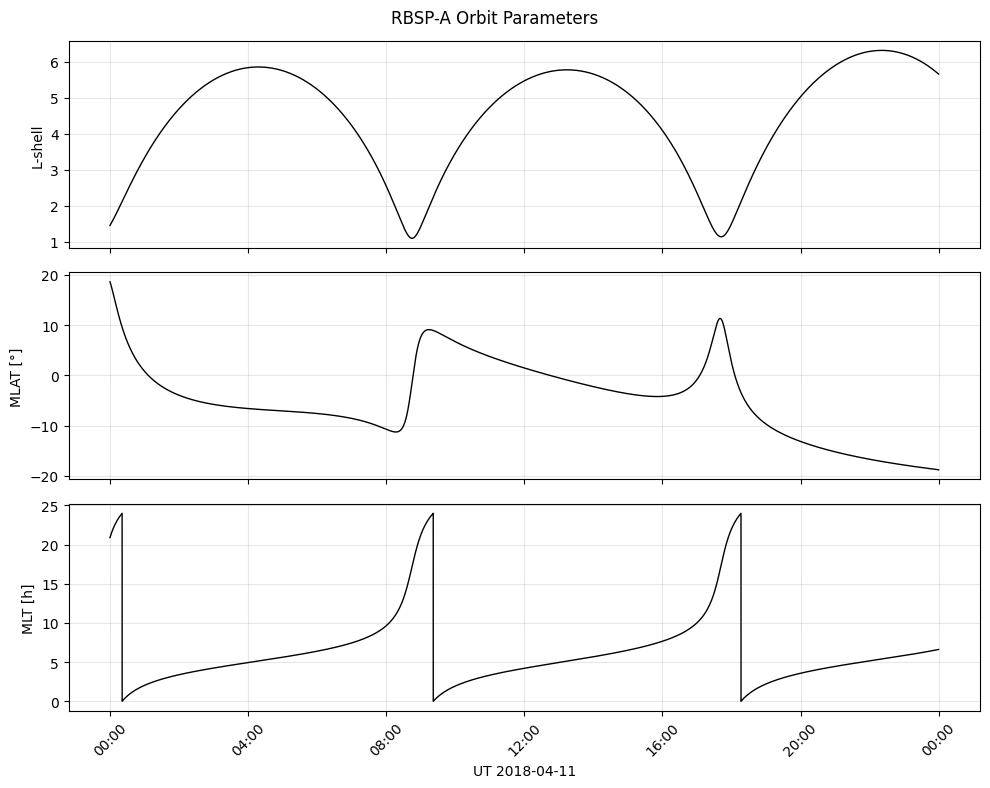

In [8]:
# Extract orbital parameters
mag_vars["Epoch"].convert_to_unit(ep.units.posixtime)
times = np.array([datetime.fromtimestamp(ts, timezone.utc) 
                  for ts in mag_vars["Epoch"].get_data()])

L = mag_vars["L"].get_data()
mlat = mag_vars["mlat"].get_data()
mlt = mag_vars["mlt"].get_data()

# Create orbital parameter plots
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
fig.suptitle("RBSP-A Orbit Parameters")

# L-shell
ax1.plot(times, L, 'k-', linewidth=1)
ax1.set_ylabel('L-shell')
ax1.grid(True, alpha=0.3)

# Magnetic latitude
ax2.plot(times, mlat, 'k-', linewidth=1)
ax2.set_ylabel(r'MLAT [°]')
ax2.grid(True, alpha=0.3)

# Magnetic local time
ax3.plot(times, mlt, 'k-', linewidth=1)
ax3.set_ylabel('MLT [h]')
ax3.set_xlabel(f'UT {times[0].strftime("%Y-%m-%d")}')
ax3.grid(True, alpha=0.3)

# Time formatting (all axes)
hours = mdates.HourLocator(interval=4)
hours_fmt = mdates.DateFormatter('%H:%M')
for ax in [ax1, ax2, ax3]:
    ax.xaxis.set_major_locator(hours)
    ax.xaxis.set_major_formatter(hours_fmt)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.show()


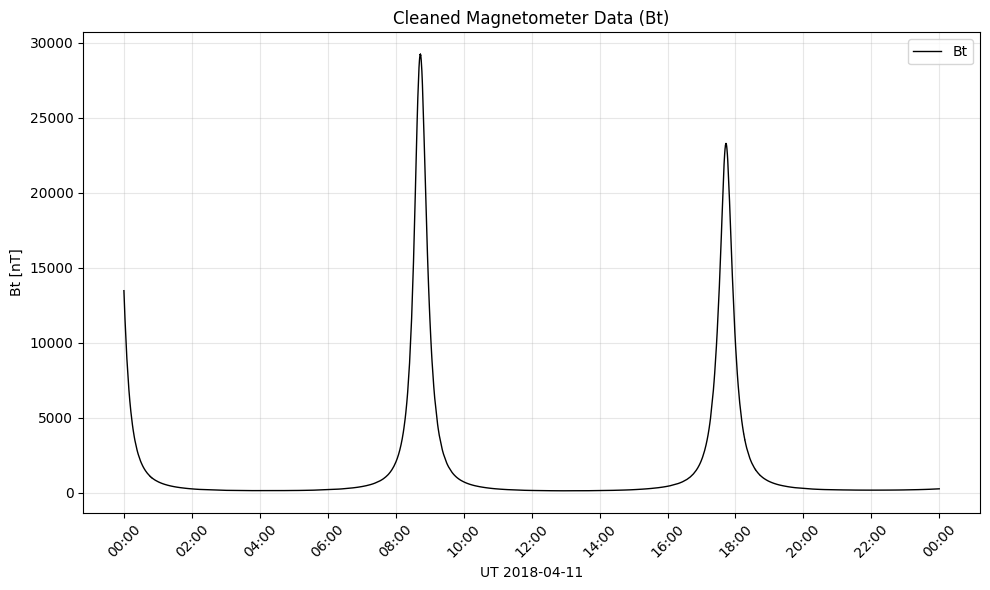

In [9]:
# Plot cleaned magnetometer data
mag_vars["Epoch"].convert_to_unit(ep.units.posixtime)
times = np.array([datetime.fromtimestamp(ts, timezone.utc) 
                  for ts in mag_vars["Epoch"].get_data()])
Bt = mag_vars["Bt"].get_data()

# Create plot
fig, ax = plt.subplots(figsize=(10, 6))

# Time series plot (no markers for cleaner look)
ax.plot(times, Bt, 'k-', linewidth=1, label='Bt')

# Formatting
ax.set_ylabel('Bt [nT]')
ax.set_xlabel(f'UT {times[0].strftime("%Y-%m-%d")}')
ax.set_title('Cleaned Magnetometer Data (Bt)')
ax.legend()
ax.grid(True, alpha=0.3)

# Time axis
hours = mdates.HourLocator(interval=2)
hours_fmt = mdates.DateFormatter('%H:%M')
ax.xaxis.set_major_locator(hours)
ax.xaxis.set_major_formatter(hours_fmt)
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.show()


In [10]:
# Save processed magnetometer data (DataOrg single-file standard)
output_file = SAVE_PATH / f"rbspa_magnetometer_{start_time.strftime('%Y%m%d')}_to_{end_time.strftime('%Y%m%d')}.pickle"

saving_strategy = ep.saving_strategies.SingleFileStrategy(output_file)

ep.save(
    variables_dict=mag_vars,  # Use cleaned+derived data
    saving_strategy=saving_strategy,
    start_time=start_time,
    end_time=end_time,
    time_var=mag_vars["Epoch"]
)


## Wave Spectrum Data (WFR)

Load RBSP-A Waveform Receiver (WFR) spectral matrix data containing power spectral densities 
from 10 Hz to 12 kHz. This data captures electromagnetic plasma waves (chorus, hiss, EMIC) and Frequency-time spectrograms for wave analysis.


In [11]:
# Extract WFR spectral matrix data (10 Hz - 12 kHz)
wfr_extraction = [
    ep.ExtractionInfo(result_key="Epoch", name_or_column="Epoch", unit=ep.units.tt2000),
    ep.ExtractionInfo(result_key="freq", name_or_column="WFR_frequencies", unit=u.Hz),
    ep.ExtractionInfo(result_key="bandwidth", name_or_column="WFR_bandwidth", unit=u.Hz),
    ep.ExtractionInfo(result_key="BuBu", name_or_column="BuBu", unit=(u.nT)**2/u.Hz),
    ep.ExtractionInfo(result_key="BvBv", name_or_column="BvBv", unit=(u.nT)**2/u.Hz),
    ep.ExtractionInfo(result_key="BwBw", name_or_column="BwBw", unit=(u.nT)**2/u.Hz),
]

# Load WFR power spectral densities
wfr_vars = ep.extract_variables_from_files(
    start_time=start_time,
    end_time=end_time,
    file_cadence="daily",
    data_path=DATA_PATH,
    file_name_stem=FILE_STEMS["wfr"],
    extraction_infos=wfr_extraction
)


In [12]:
# Compute total magnetic power spectral density |B|^2 = |Bu|^2 + |Bv|^2 + |Bw|^2
BB = (wfr_vars["BuBu"].get_data() + 
      wfr_vars["BvBv"].get_data() + 
      wfr_vars["BwBw"].get_data())

# Add total PSD as new variable
wfr_vars["BB"] = Variable((u.nT)**2 / u.Hz, data=BB)

# Extract frequency axis (constant across time) 
freq = wfr_vars["freq"].get_data()[0]
wfr_vars["freq"].set_data(freq, unit="same")

bandwidth = wfr_vars["bandwidth"].get_data()[0]
wfr_vars["bandwidth"].set_data(bandwidth, unit="same")

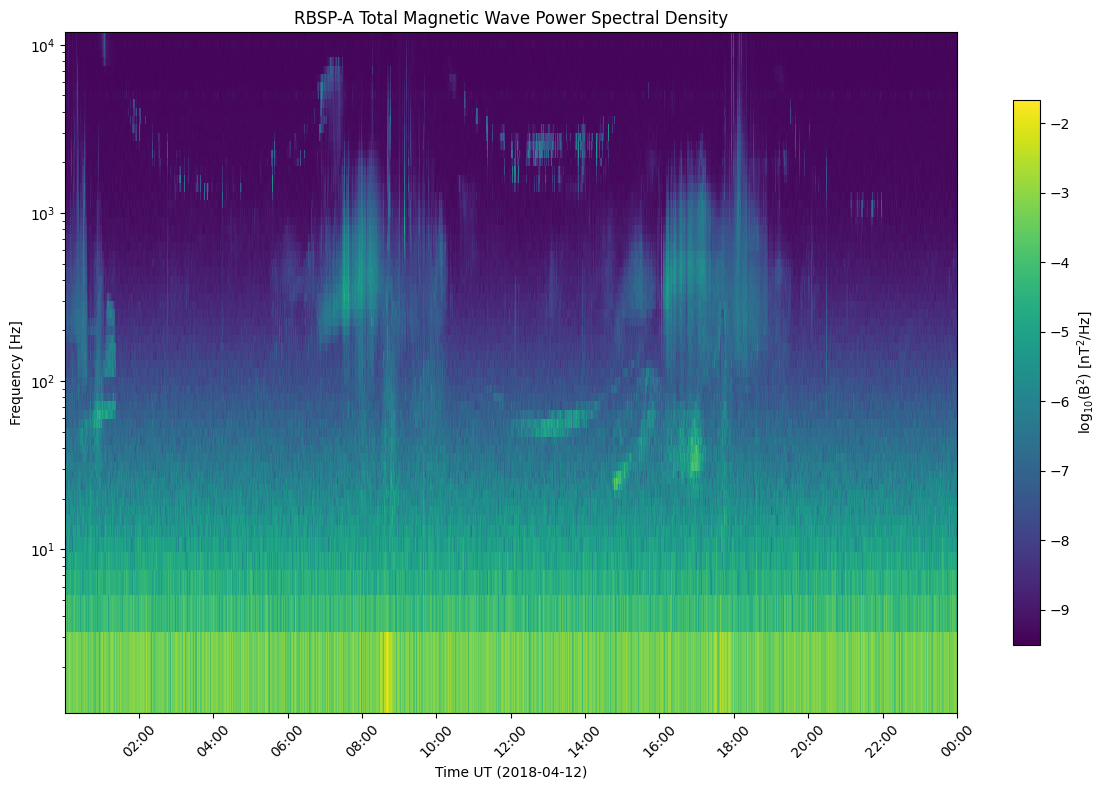

In [13]:
# Create wave spectrogram
wfr_vars["Epoch"].convert_to_unit(ep.units.posixtime)
times = np.array([datetime.fromtimestamp(ts, timezone.utc) 
                  for ts in wfr_vars["Epoch"].get_data()])

frequency = wfr_vars["freq"].get_data() 

# Plot spectrogram
fig, ax = plt.subplots(figsize=(12, 8))

# log10 PSD spectrogram (chorus waves visible 0.1-5 kHz)
cax = ax.pcolormesh(times, frequency, np.log10(BB.T),  cmap='viridis')

# Time axis formatting
hours = mdates.HourLocator(interval=2)
hours_fmt = mdates.DateFormatter('%H:%M')
ax.xaxis.set_major_locator(hours)
ax.xaxis.set_major_formatter(hours_fmt)
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
ax.set_xlabel(f'Time UT ({times[0].strftime("%Y-%m-%d")})')

# Frequency axis (log scale for chorus/hiss)
ax.set_yscale('log')
ax.set_ylabel('Frequency [Hz]')

# Colorbar with proper units
cbar = fig.colorbar(cax, ax=ax, shrink=0.8)
cbar.set_label(r'log$_{10}$(B$^2$) [nT$^2$/Hz]')

ax.set_title('RBSP-A Total Magnetic Wave Power Spectral Density')
plt.tight_layout()
plt.show()


In [14]:
# Save WFR spectral data (minimal subset for analysis)
wave_vars = {key: wfr_vars[key] for key in ["Epoch", "BuBu", "BvBv", "BwBw", "BB"]}

output_file = SAVE_PATH / f"rbspa_wave_spectrum_{start_time.strftime('%Y%m%d')}_to_{end_time.strftime('%Y%m%d')}.pickle"

saving_strategy = ep.saving_strategies.SingleFileStrategy(output_file)

ep.save(
    variables_dict=wave_vars,
    saving_strategy=saving_strategy,
    start_time=start_time,
    end_time=end_time,
    time_var=wave_vars["Epoch"] 
)


> NOTE: EL PASO requires time dimension + specific axis order

 1. ALL variables MUST have time dimension to save (no scalars allowed)
 2. Spectrogram data: order matters - (freq,time) fails to save  

## Wave Properties Data

Load pre-computed wave normal angle analysis and sheath-corrected wave properties 
from EMFISIS L4 product.


In [15]:
# Extract wave normal analysis (WNA) properties from L4 product
wna_extraction = [
    ep.ExtractionInfo(result_key="Epoch", name_or_column="Epoch", unit=ep.units.tt2000),
    ep.ExtractionInfo(result_key="freq", name_or_column="WFR_frequencies", unit=u.Hz),
    ep.ExtractionInfo(result_key="WNA", name_or_column="thsvd", unit=u.deg),  # Wave normal angle
    ep.ExtractionInfo(result_key="ellipticity", name_or_column="ellsvd", unit=u.dimensionless_unscaled),
    ep.ExtractionInfo(result_key="planarity", name_or_column="plansvd", unit=u.dimensionless_unscaled),
]

# Load sheath-corrected wave properties
wna_vars = ep.extract_variables_from_files(
    start_time=start_time,
    end_time=end_time,
    file_cadence="daily",
    data_path=DATA_PATH,
    file_name_stem=FILE_STEMS["wave_properties"],
    extraction_infos=wna_extraction
)


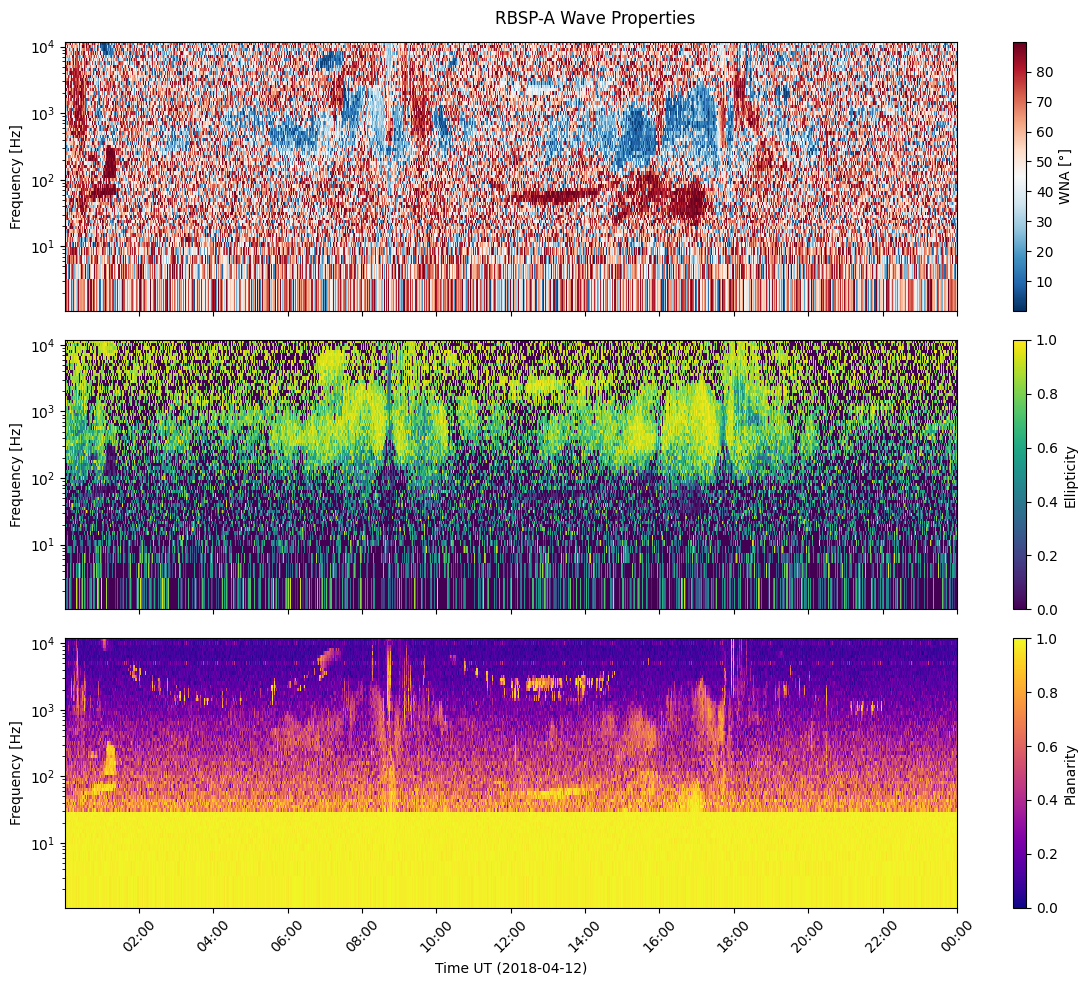

In [16]:
# Plot wave normal analysis properties (spectrograms)
wna_vars["Epoch"].convert_to_unit(ep.units.posixtime)
times = np.array([datetime.fromtimestamp(ts, timezone.utc) 
                  for ts in wna_vars["Epoch"].get_data()])
freq = wna_vars["freq"].get_data()  # 1D frequency axis

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
fig.suptitle('RBSP-A Wave Properties')

# 1. Wave Normal Angle (WNA)
cax1 = ax1.pcolormesh(times, freq, wna_vars['WNA'].get_data().T, 
                      cmap='RdBu_r', shading='auto')
ax1.set_ylabel('Frequency [Hz]')
ax1.set_yscale('log')
fig.colorbar(cax1, ax=ax1, label='WNA [°]')

# 2. Ellipticity
cax2 = ax2.pcolormesh(times, freq, wna_vars['ellipticity'].get_data().T, 
                      vmin=0, vmax=1, cmap='viridis', shading='auto')
ax2.set_ylabel('Frequency [Hz]')
ax2.set_yscale('log')
fig.colorbar(cax2, ax=ax2, label='Ellipticity')

# 3. Planarity
cax3 = ax3.pcolormesh(times, freq, wna_vars['planarity'].get_data().T, 
                      vmin=0, vmax=1, cmap='plasma', shading='auto')
date_str = times[0].strftime("%Y-%m-%d")
ax3.set_xlabel(f'Time UT ({date_str})')
ax3.set_ylabel('Frequency [Hz]')
ax3.set_yscale('log')
fig.colorbar(cax3, ax=ax3, label='Planarity')

# Time formatting (bottom axis only)
hours = mdates.HourLocator(interval=2)
hours_fmt = mdates.DateFormatter('%H:%M')
ax3.xaxis.set_major_locator(hours)
ax3.xaxis.set_major_formatter(hours_fmt)
plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.show()


In [ ]:
# Save wave properties (WNA analysis)
waveprop_vars = {key: wna_vars[key] for key in ["Epoch", "WNA", "ellipticity", "planarity",]}

output_file = SAVE_PATH / f"rbspa_wave_properties_{start_time.strftime('%Y%m%d')}_to_{end_time.strftime('%Y%m%d')}.pickle"

saving_strategy = ep.saving_strategies.SingleFileStrategy(output_file)

ep.save(
    variables_dict=waveprop_vars,
    saving_strategy=saving_strategy,
    start_time=start_time,
    end_time=end_time,
    time_var=waveprop_vars["Epoch"]
)
